Mounted at /content/drive
Imagen cargada exitosamente. Dimensiones: (2238, 2677, 3)
Se detectaron 85 círculos

Información de los círculos detectados:
(Centro X, Centro Y, Radio)
Círculo 1: Centro=(412, 240), Radio=52
Círculo 2: Centro=(434, 140), Radio=52
Círculo 3: Centro=(444, 1432), Radio=99
Círculo 4: Centro=(470, 664), Radio=49
Círculo 5: Centro=(520, 242), Radio=51
Círculo 6: Centro=(1476, 1984), Radio=99
Círculo 7: Centro=(1382, 1852), Radio=88
Círculo 8: Centro=(594, 1398), Radio=91
Círculo 9: Centro=(1298, 2052), Radio=95
Círculo 10: Centro=(324, 1362), Radio=92
Círculo 11: Centro=(1228, 1704), Radio=99
Círculo 12: Centro=(1508, 1388), Radio=60
Círculo 13: Centro=(558, 114), Radio=64
Círculo 14: Centro=(1572, 2050), Radio=91
Círculo 15: Centro=(1396, 2120), Radio=90
Círculo 16: Centro=(1714, 656), Radio=49
Círculo 17: Centro=(1012, 882), Radio=91
Círculo 18: Centro=(2544, 1074), Radio=89
Círculo 19: Centro=(1334, 1764), Radio=78
Círculo 20: Centro=(1442, 1768), Radio=91
Círcu

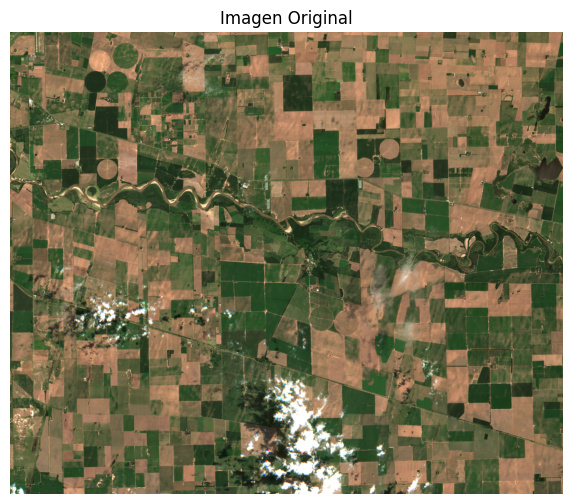

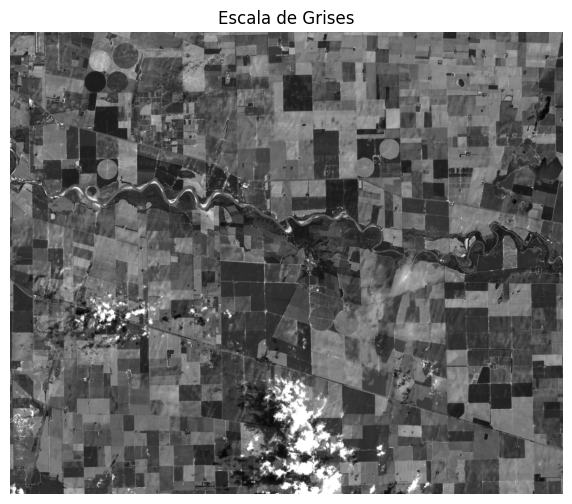

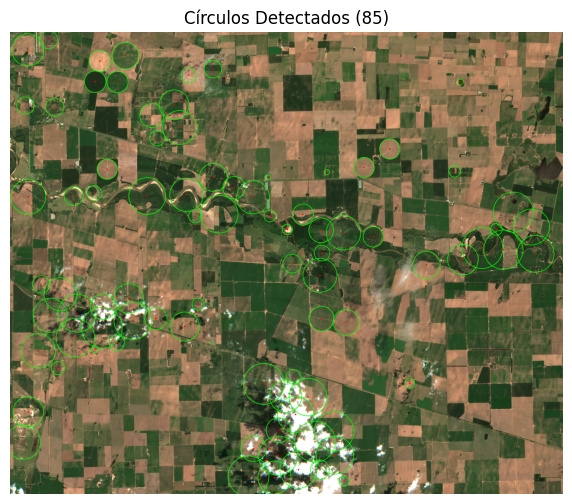

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Importar librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ruta de la imagen en Drive (ajusta según tu estructura de carpetas)
ruta_imagen = '/content/drive/My Drive/GEO_DS/Recorte_R4/Recorte_R4.tif'

# Leer la imagen
imagen = cv2.imread(ruta_imagen)

if imagen is None:
    print(f"Error: No se pudo cargar la imagen en {ruta_imagen}")
    print("Verifica que el archivo exista y la ruta sea correcta")
else:
    print(f"Imagen cargada exitosamente. Dimensiones: {imagen.shape}")

    # Convertir a escala de grises
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

    # Aplicar desenfoque gaussiano para reducir ruido
    gris_blur = cv2.medianBlur(gris, 5)

    # Aplicar Hough Circle Transform
    # Parámetros:
    # - imagen en escala de grises
    # - método de detección (HOUGH_GRADIENT)
    # - dp: resolución del acumulador (1 = misma resolución que la imagen)
    # - minDist: distancia mínima entre centros de círculos detectados
    # - param1: umbral superior para Canny edge detector
    # - param2: umbral del acumulador para centros de círculos
    # - minRadius y maxRadius: rango de radios a detectar

    circulos = cv2.HoughCircles(
        gris_blur,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=100,
        param1=100,
        param2=30,
        minRadius=10,
        maxRadius=100
    )

    # Crear copia de la imagen original para dibujar
    imagen_resultado = imagen.copy()

    if circulos is not None:
        # Convertir a enteros
        circulos = np.uint16(np.around(circulos))

        print(f"Se detectaron {len(circulos[0])} círculos")

        # Dibujar los círculos detectados
        for i in circulos[0, :]:
            # Dibujar el círculo exterior
            cv2.circle(imagen_resultado, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Dibujar el centro del círculo
            cv2.circle(imagen_resultado, (i[0], i[1]), 2, (0, 0, 255), 3)

        print("\nInformación de los círculos detectados:")
        print("(Centro X, Centro Y, Radio)")
        for idx, i in enumerate(circulos[0, :]):
            print(f"Círculo {idx+1}: Centro=({i[0]}, {i[1]}), Radio={i[2]}")
    else:
        print("No se detectaron círculos. Intenta ajustar los parámetros.")

    # Visualizar resultados separadamente

    # Imagen original
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title('Imagen Original')
    plt.axis('off')
    plt.show()

    # Imagen en escala de grises
    plt.figure(figsize=(8, 6))
    plt.imshow(gris, cmap='gray')
    plt.title('Escala de Grises')
    plt.axis('off')
    plt.show()

    # Imagen con círculos detectados
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(imagen_resultado, cv2.COLOR_BGR2RGB))
    plt.title(f'Círculos Detectados ({len(circulos[0]) if circulos is not None else 0})')
    plt.axis('off')
    plt.show()

    # Guardar imagen resultante (opcional)
    #ruta_salida = '/content/drive/MyDrive/Recorte_R4_circulos.png'
    #cv2.imwrite(ruta_salida, imagen_resultado)
    #print(f"\nImagen con círculos guardada en: {ruta_salida}")